# 03 — Exploratory Data Analysis (EDA)
Compute descriptive statistics and generate visualisations for all feature types.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from preprocessing import preprocess, get_feature_types
from eda import (
    numerical_stats, categorical_stats,
    plot_histogram, plot_kde, plot_boxplot, plot_categorical_bar
)

## 1. Load & Preprocess

In [2]:
ref_df = preprocess(pd.read_csv('../data/reference.csv'))
cur_df = preprocess(pd.read_csv('../data/current.csv'))
ft = get_feature_types(ref_df)
num_cols = ft['numerical']
cat_cols = ft['categorical']
print('Numerical:', num_cols)
print('Categorical:', cat_cols)

Numerical: ['age', 'income', 'credit_score', 'loan_amount', 'employment_years', 'default']
Categorical: ['education', 'loan_purpose']


/Users/animeshsingh/Downloads/ML-Data-Drift-Dashboard/notebooks/../src/preprocessing.py:63: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  parsed = pd.to_datetime(sample, infer_datetime_format=True, errors="coerce")
/Users/animeshsingh/Downloads/ML-Data-Drift-Dashboard/notebooks/../src/preprocessing.py:63: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(sample, infer_datetime_format=True, errors="coerce")
/Users/animeshsingh/Downloads/ML-Data-Drift-Dashboard/notebooks/../src/preprocessing.py:63: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict versi

## 2. Numerical Statistics

In [3]:
print('=== Reference ===' )
display(numerical_stats(ref_df, num_cols))
print('=== Current ===')
display(numerical_stats(cur_df, num_cols))

=== Reference ===


,feature,mean,median,std,variance,min,max,count
0,age,35.125,33.5,9.4223,8.877880e+01,21,55,40
1,income,68150.000,62000.0,30889.0073,9.541308e+08,27000,145000,40
2,credit_score,705.175,700.0,63.9547,4.090199e+03,595,820,40
3,loan_amount,30437.500,18500.0,29543.7935,8.728357e+08,4000,120000,40
4,employment_years,8.800,7.0,6.6802,4.462560e+01,1,25,40
5,default,0.225,0.0,0.4229,1.788000e-01,0,1,40


=== Current ===


,feature,mean,median,std,variance,min,max,count
0,age,39.300,37.5,9.6535,9.318970e+01,25,60,40
1,income,81775.000,74500.0,38147.1426,1.455204e+09,32000,170000,40
2,credit_score,695.175,690.0,63.9547,4.090199e+03,585,810,40
3,loan_amount,39262.500,24500.0,37907.9498,1.437013e+09,5500,150000,40
4,employment_years,11.125,9.0,7.4047,5.483010e+01,2,28,40
5,default,0.425,0.0,0.5006,2.506000e-01,0,1,40


## 3. Numerical Visualisations

/Users/animeshsingh/Downloads/ML-Data-Drift-Dashboard/notebooks/../src/eda.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="Dataset", y=col, palette=PALETTE, ax=ax)


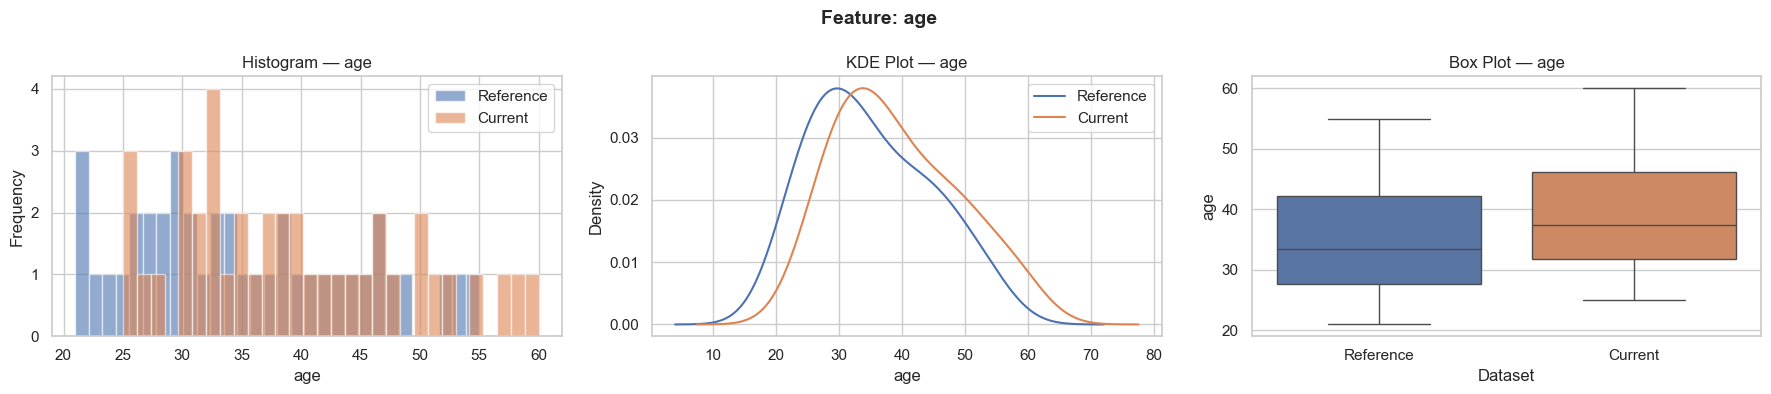

/Users/animeshsingh/Downloads/ML-Data-Drift-Dashboard/notebooks/../src/eda.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="Dataset", y=col, palette=PALETTE, ax=ax)


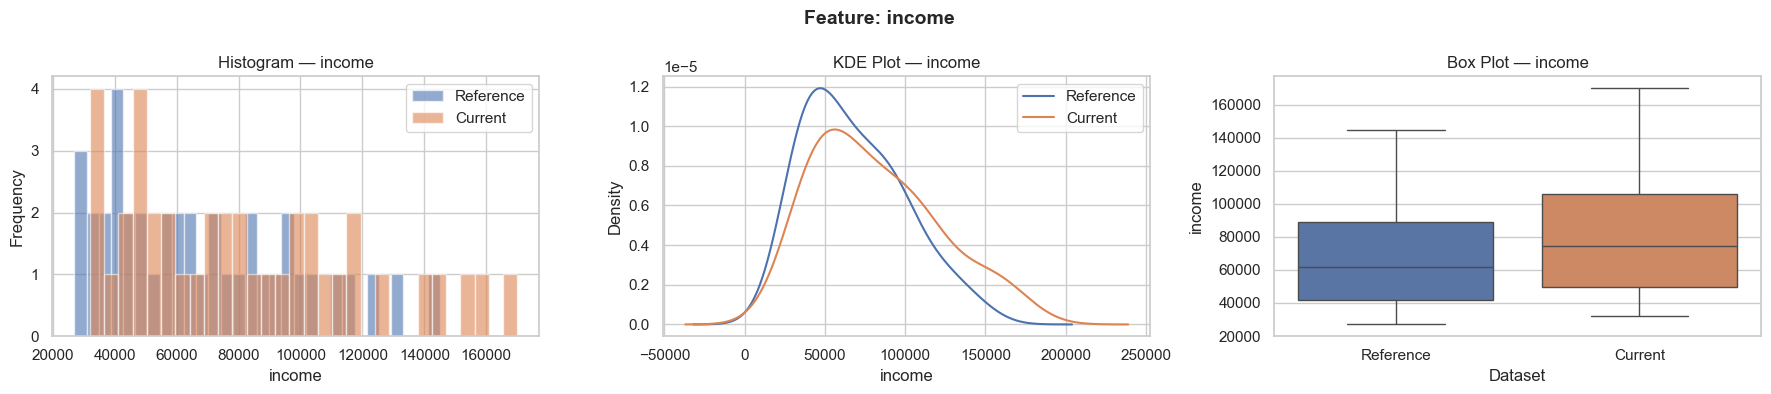

/Users/animeshsingh/Downloads/ML-Data-Drift-Dashboard/notebooks/../src/eda.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="Dataset", y=col, palette=PALETTE, ax=ax)


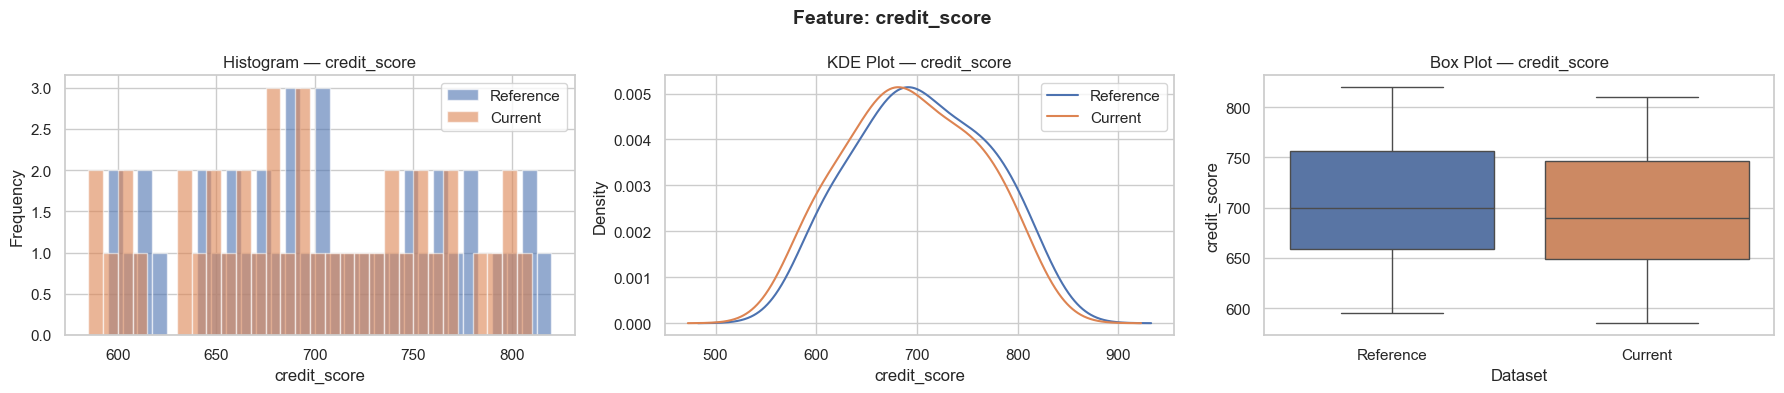

In [4]:
for col in num_cols[:3]:  # show first 3 features
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    plot_histogram(ref_df, cur_df, col, ax=axes[0])
    plot_kde(ref_df, cur_df, col, ax=axes[1])
    plot_boxplot(ref_df, cur_df, col, ax=axes[2])
    plt.suptitle(f'Feature: {col}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4. Categorical Statistics

In [5]:
cat_s = categorical_stats(ref_df, cat_cols)
for col, info in cat_s.items():
    print(f"\n{col}: {info['unique_values']} unique values | Mode: {info['mode']}")
    display(info['value_counts'].head())


education: 4 unique values | Mode: Bachelor


,count,count
0,Bachelor,18
1,Master,10
2,PhD,7
3,High School,5



loan_purpose: 4 unique values | Mode: personal


,count,count
0,personal,12
1,business,11
2,home,9
3,auto,8


## 5. Categorical Visualisations

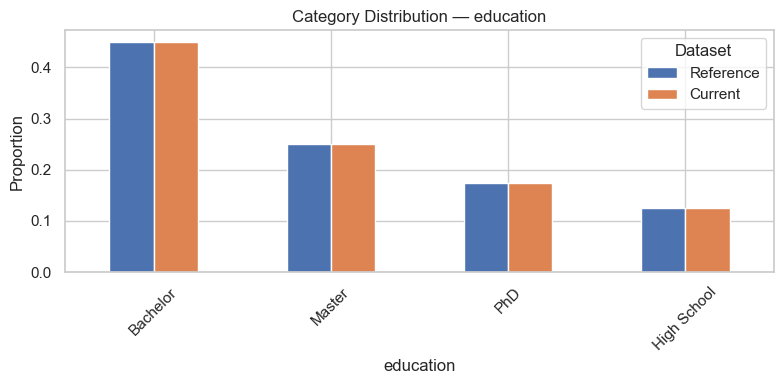

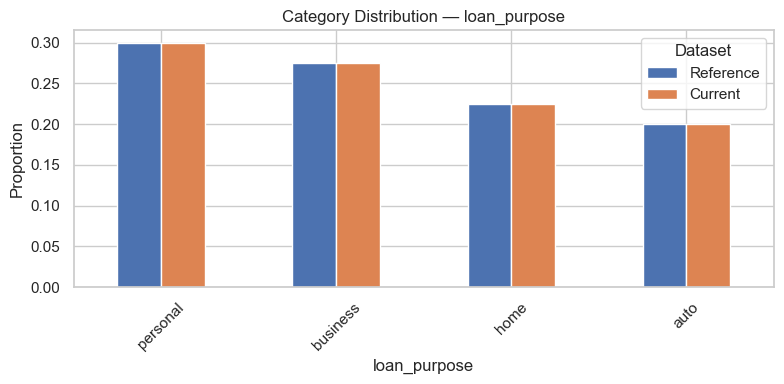

In [6]:
for col in cat_cols:
    fig = plot_categorical_bar(ref_df, cur_df, col)
    plt.show()
    plt.close(fig)